# Entrega 1 — Análise Comparativa de Representações

**Ouvidoria Inteligente: Triagem Semântica de Manifestações Cidadãs**

Objetivo: comparar representações **esparsas** (Bag-of-Words e TF-IDF) com representações **densas** (embeddings de sentenças) no corpus das 40 manifestações, calculando a similaridade de cosseno para três pares de referência:

| Par | Relação esperada |
|---|---|
| M003 × M017 | mesmo problema (buraco na Av. Brasil) descrito com palavras diferentes → **deveriam ser parecidas** |
| M008 × M022 | mesmo problema (unidade de saúde sem médico) → **deveriam ser parecidas** |
| M008 × M031 | temas diferentes (saúde × iluminação) → **não deveriam ser parecidas** |

> **Sobre os dados:** o arquivo `manifestacoes.json` usado aqui é um dataset de exemplo construído segundo a especificação do desafio (40 manifestações, 5 categorias, ~15% de duplicatas semânticas e 5 textos longos). Todo o código lê o arquivo JSON, então basta substituí-lo pelo arquivo oficial e reexecutar o notebook.

## 1. Configuração

In [1]:
import json
import os
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from transformers.utils import logging as hf_logging
from huggingface_hub.utils import disable_progress_bars, logging as hub_logging

# Silencia barras de progresso e avisos de download dos modelos
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()
disable_progress_bars()
hub_logging.set_verbosity_error()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

MODELOS = {
    "MiniLM (multilingual-MiniLM-L12-v2)": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "mpnet (multilingual-mpnet-base-v2)": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
}
PARES = [("M003", "M017"), ("M008", "M022"), ("M008", "M031")]

## 2. Carregando o corpus

In [2]:
with open("manifestacoes.json", encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))

df["n_caracteres"] = df["texto"].str.len()
print(f"{len(df)} manifestações | {df['categoria_oficial'].nunique()} categorias")
df.head()

40 manifestações | 5 categorias


,id,data,categoria_oficial,texto,n_caracteres
0,M001,2026-08-01,infraestrutura,A calçada da Rua Tiradentes está toda quebrada em frente ao número 230. Idosos já caíram tentando passar por ali.,113
1,M002,2026-08-01,saúde,Falta de remédio no posto do bairro Santa Luzia: já é o segundo mês sem losartana para pressão na farmácia da unidade.,118
2,M003,2026-08-02,infraestrutura,"Tem um buraco enorme na Av. Brasil, perto do cruzamento com a Rua XV. Os carros desviam em cima da hora e quase acon...",132
3,M004,2026-08-02,segurança,Não tem policiamento nenhum na Praça da Matriz à noite. Os moradores estão com medo de sair de casa depois das 20h.,115
4,M005,2026-08-03,educação,A Escola Municipal Castro Alves está sem professor de matemática desde o início do semestre. Os alunos ficam com aul...,123


In [3]:
df.groupby("categoria_oficial").agg(quantidade=("id", "count"), media_caracteres=("n_caracteres", "mean")).round(0)

,quantidade,media_caracteres
categoria_oficial,,
educação,8,186.0
infraestrutura,10,172.0
meio ambiente,8,179.0
saúde,7,194.0
segurança,7,193.0


In [4]:
# Índice rápido id -> posição na lista, usado em todo o notebook
pos = {id_: i for i, id_ in enumerate(df["id"])}
textos = df["texto"].tolist()

for a, b in PARES:
    print(f"{a}: {df.loc[pos[a], 'texto']}")
    print(f"{b}: {df.loc[pos[b], 'texto']}\n")

M003: Tem um buraco enorme na Av. Brasil, perto do cruzamento com a Rua XV. Os carros desviam em cima da hora e quase acontecem acidentes.
M017: Asfalto todo esburacado da avenida principal (Av. Brasil), principalmente perto da Rua XV. Já estourei um pneu ali semana passada.

M008: Posto de saúde sem médico no Jardim América há duas semanas. Chegamos cedo e voltamos para casa sem atendimento.
M022: Falta atendimento no PSF do Jardim América: a unidade está sem clínico geral faz quinze dias e mandam todo mundo para a UPA.

M008: Posto de saúde sem médico no Jardim América há duas semanas. Chegamos cedo e voltamos para casa sem atendimento.
M031: Lâmpada queimada na praça do bairro São Cristóvão, perto do parquinho. As crianças não conseguem brincar depois que escurece.



## 3. Pré-processamento para as representações esparsas

BoW e TF-IDF dependem da coincidência exata de tokens, então aplicamos uma normalização simples:
minúsculas, remoção de acentos (para que "saúde" e "saude" sejam o mesmo token) e remoção de *stopwords* do português.
Os embeddings recebem o texto original, pois os modelos de sentença foram treinados com texto natural.

In [5]:
STOPWORDS_PT = set('''
a à ao aos as às até com como da das de dela dele deles do dos e é ela ele eles em entre era essa esse esta está
estão este eu foi foram há isso isto já la lá mais mas me mesmo meu minha muito na nas não nem no nos nós o os ou
para pela pelas pelo pelos por qual quando que quem se sem ser seu sua são só também te tem tinha um uma umas uns
vai vão você ali aqui ter todo toda todos todas nesta neste nessa nesse desde após sobre porque pois então
'''.split())


def remover_acentos(texto):
    return "".join(c for c in unicodedata.normalize("NFD", texto) if unicodedata.category(c) != "Mn")


STOPWORDS_NORM = {remover_acentos(w) for w in STOPWORDS_PT}


def normalizar(texto):
    return remover_acentos(texto.lower())


def tokens(texto):
    return [t for t in re.findall(r"\b\w\w+\b", normalizar(texto)) if t not in STOPWORDS_NORM]


print(tokens(textos[pos["M003"]]))

['buraco', 'enorme', 'av', 'brasil', 'perto', 'cruzamento', 'rua', 'xv', 'carros', 'desviam', 'cima', 'hora', 'quase', 'acontecem', 'acidentes']


## 4. Bag-of-Words (BoW)

In [6]:
bow = CountVectorizer(preprocessor=normalizar, stop_words=sorted(STOPWORDS_NORM))
X_bow = bow.fit_transform(textos)
print(f"Matriz BoW: {X_bow.shape[0]} documentos x {X_bow.shape[1]} termos | "
      f"esparsidade: {1 - X_bow.nnz / np.prod(X_bow.shape):.1%}")

vetor_m003 = pd.Series(X_bow[pos["M003"]].toarray()[0], index=bow.get_feature_names_out())
vetor_m003[vetor_m003 > 0]

Matriz BoW: 40 documentos x 516 termos | esparsidade: 96.5%


acidentes     1
acontecem     1
av            1
brasil        1
buraco        1
carros        1
cima          1
cruzamento    1
desviam       1
enorme        1
hora          1
perto         1
quase         1
rua           1
xv            1
dtype: int64

## 5. TF-IDF

In [7]:
tfidf = TfidfVectorizer(preprocessor=normalizar, stop_words=sorted(STOPWORDS_NORM))
X_tfidf = tfidf.fit_transform(textos)
print(f"Matriz TF-IDF: {X_tfidf.shape}")

# Termos de maior peso em M003: palavras raras no corpus recebem peso maior
pesos = pd.Series(X_tfidf[pos["M003"]].toarray()[0], index=tfidf.get_feature_names_out())
pesos.sort_values(ascending=False).head(8).round(3)

Matriz TF-IDF: (40, 516)


desviam       0.285
quase         0.285
cima          0.285
enorme        0.285
acontecem     0.285
acidentes     0.285
cruzamento    0.257
carros        0.257
dtype: float64

## 6. Embeddings densos (Sentence-BERT)

Comparamos dois modelos multilíngues da biblioteca `sentence-transformers`:

* **paraphrase-multilingual-MiniLM-L12-v2** — 384 dimensões, leve e rápido;
* **paraphrase-multilingual-mpnet-base-v2** — 768 dimensões, maior e em geral mais preciso.

(O modelo `BAAI/bge-small-pt-v1.5` citado no enunciado não está disponível publicamente no Hugging Face, por isso usamos o mpnet como segundo modelo.)
Os vetores são normalizados (norma 1), então o produto escalar é igual à similaridade de cosseno.

In [8]:
embeddings, modelos = {}, {}
for nome, caminho in MODELOS.items():
    modelos[nome] = modelo = SentenceTransformer(caminho)
    embeddings[nome] = modelo.encode(textos, normalize_embeddings=True)
    print(f"{nome}: {embeddings[nome].shape}")

MiniLM (multilingual-MiniLM-L12-v2): (40, 384)


mpnet (multilingual-mpnet-base-v2): (40, 768)


## 7. Similaridade de cosseno nos três pares

In [9]:
matrizes = {"BoW": cosine_similarity(X_bow), "TF-IDF": cosine_similarity(X_tfidf)}
for nome, E in embeddings.items():
    matrizes[nome.split(" ")[0]] = cosine_similarity(E)

tabela = pd.DataFrame(
    {rep: [S[pos[a], pos[b]] for a, b in PARES] for rep, S in matrizes.items()},
    index=[f"{a} × {b}" for a, b in PARES],
).round(3)
tabela.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None).format("{:.3f}")

,BoW,TF-IDF,MiniLM,mpnet
M003 × M017,0.345,0.263,0.680,0.771
M008 × M022,0.231,0.193,0.643,0.589
M008 × M031,0.000,0.000,0.142,0.144


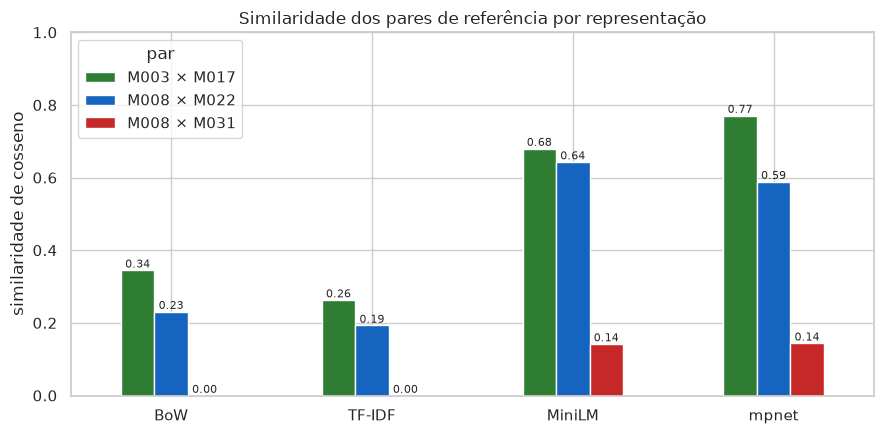

In [10]:
ax = tabela.T.plot(kind="bar", figsize=(9, 4.5), color=["#2e7d32", "#1565c0", "#c62828"], rot=0)
ax.set_ylabel("similaridade de cosseno")
ax.set_title("Similaridade dos pares de referência por representação")
ax.set_ylim(0, 1)
ax.legend(title="par")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8)
plt.tight_layout()
plt.savefig("figuras/e1_pares_por_representacao.png", dpi=150)
plt.show()

### 7.1 Por que BoW e TF-IDF ficam baixos? Olhando o vocabulário compartilhado

As representações esparsas só "enxergam" a sobreposição literal de termos. Abaixo, os tokens em comum de cada par, após a normalização:

In [11]:
linhas = []
for a, b in PARES:
    ta, tb = set(tokens(textos[pos[a]])), set(tokens(textos[pos[b]]))
    linhas.append({
        "par": f"{a} × {b}",
        "termos em comum": ", ".join(sorted(ta & tb)) or "(nenhum)",
        "só no 1º": ", ".join(sorted(ta - tb)),
        "só no 2º": ", ".join(sorted(tb - ta)),
    })
pd.DataFrame(linhas).set_index("par")

,termos em comum,só no 1º,só no 2º
par,,,
M003 × M017,"av, brasil, perto, rua, xv","acidentes, acontecem, buraco, carros, cima, cruzamento, desviam, enorme, hora, quase","asfalto, avenida, esburacado, estourei, passada, pneu, principal, principalmente, semana"
M008 × M022,"america, atendimento, jardim","casa, cedo, chegamos, duas, medico, posto, saude, semanas, voltamos","clinico, dias, falta, faz, geral, mandam, mundo, psf, quinze, unidade, upa"
M008 × M031,(nenhum),"america, atendimento, casa, cedo, chegamos, duas, jardim, medico, posto, saude, semanas, voltamos","bairro, brincar, conseguem, criancas, cristovao, depois, escurece, lampada, parquinho, perto, praca, queimada"


### 7.2 Os valores absolutos não são comparáveis entre representações

Um cosseno de 0,35 em BoW não significa o mesmo que 0,35 em um embedding: cada representação tem uma **distribuição de base** diferente
(embeddings raramente chegam perto de 0, mesmo para textos sem relação). Por isso, além do valor bruto, calculamos o **percentil** de cada par
em relação a todos os 780 pares possíveis do corpus — isto é, "quão acima do típico" o par está naquela representação.

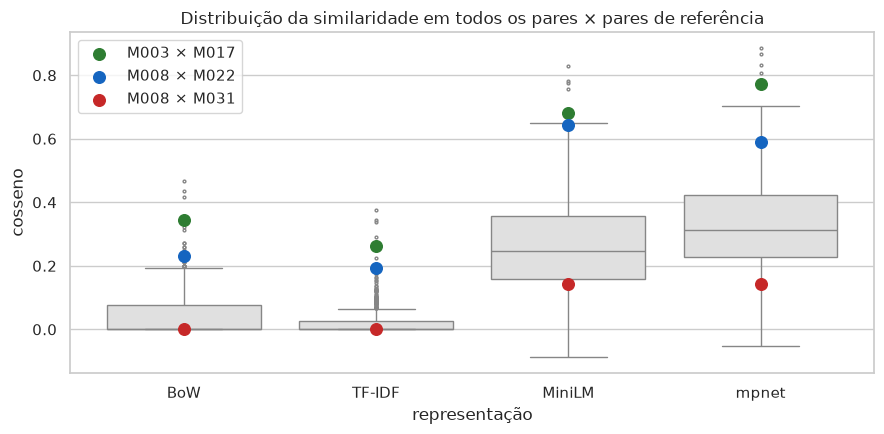

Percentil de cada par dentro da distribuição da própria representação (%):


,BoW,TF-IDF,MiniLM,mpnet
M003 × M017,99.4,99.2,99.2,99.4
M008 × M022,97.9,99.0,98.8,95.3
M008 × M031,0.0,0.0,19.7,9.4


In [12]:
iu = np.triu_indices(len(df), k=1)  # todos os pares i < j

fig, ax = plt.subplots(figsize=(9, 4.5))
dist = pd.DataFrame({rep: S[iu] for rep, S in matrizes.items()}).melt(var_name="representação", value_name="cosseno")
sns.boxplot(data=dist, x="representação", y="cosseno", color="#e0e0e0", ax=ax, fliersize=2)
cores = {"M003 × M017": "#2e7d32", "M008 × M022": "#1565c0", "M008 × M031": "#c62828"}
for k, rep in enumerate(matrizes):
    for par, cor in cores.items():
        ax.scatter(k, tabela.loc[par, rep], color=cor, s=70, zorder=3, label=par if k == 0 else None)
ax.set_title("Distribuição da similaridade em todos os pares × pares de referência")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("figuras/e1_distribuicao_pares.png", dpi=150)
plt.show()

percentis = pd.DataFrame(
    {rep: [(S[iu] < S[pos[a], pos[b]]).mean() * 100 for a, b in PARES] for rep, S in matrizes.items()},
    index=tabela.index,
).round(1)
print("Percentil de cada par dentro da distribuição da própria representação (%):")
percentis

### 7.3 Vizinho mais próximo de cada manifestação do par

Outra forma de avaliar: se buscarmos a manifestação mais parecida com M003 (e com M008), a representação encontra o par correto?

In [13]:
def vizinhos(S, id_, k=3):
    s = S[pos[id_]].copy()
    s[pos[id_]] = -1  # ignora o próprio documento
    ordem = np.argsort(-s)[:k]
    return ", ".join(f"{df.loc[i, 'id']} ({s[i]:.2f})" for i in ordem)


pd.DataFrame({rep: {f"top-3 de {q}": vizinhos(S, q) for q in ["M003", "M017", "M008", "M022"]}
              for rep, S in matrizes.items()})

,BoW,TF-IDF,MiniLM,mpnet
top-3 de M003,"M017 (0.35), M023 (0.23), M028 (0.16)","M017 (0.26), M023 (0.16), M028 (0.10)","M017 (0.68), M001 (0.60), M025 (0.60)","M017 (0.77), M036 (0.70), M023 (0.69)"
top-3 de M017,"M003 (0.35), M010 (0.20), M006 (0.18)","M003 (0.26), M006 (0.10), M023 (0.09)","M003 (0.68), M001 (0.66), M006 (0.57)","M003 (0.77), M036 (0.64), M001 (0.63)"
top-3 de M008,"M022 (0.23), M004 (0.09), M035 (0.09)","M022 (0.19), M035 (0.09), M034 (0.07)","M022 (0.64), M015 (0.62), M002 (0.58)","M022 (0.59), M015 (0.54), M034 (0.54)"
top-3 de M022,"M008 (0.23), M002 (0.15), M015 (0.15)","M008 (0.19), M002 (0.12), M015 (0.12)","M008 (0.64), M015 (0.56), M002 (0.50)","M015 (0.59), M008 (0.59), M002 (0.51)"


### 7.4 Teste controlado: as frases curtas do enunciado

No corpus, os pares duplicados compartilham **nomes de lugar** ("Av. Brasil", "Rua XV", "Jardim América"), e é isso que sustenta a similaridade
esparsa — não o problema descrito. Para isolar o efeito semântico, repetimos a comparação só com as frases resumidas do enunciado,
sem nenhum nome próprio em comum. O vocabulário do BoW/TF-IDF é ajustado ao corpus completo, como em produção.

In [14]:
FRASES = {
    "M003 × M017": ("buraco enorme na Av. Brasil", "asfalto todo esburacado da avenida principal"),
    "M008 × M022": ("posto de saúde sem médico", "falta atendimento no PSF"),
    "M008 × M031": ("posto de saúde sem médico", "lâmpada queimada na praça"),
}


def cos_esparso(vetorizador, a, b):
    X = vetorizador.transform([a, b])
    return cosine_similarity(X)[0, 1]


curtas = {}
for par, (a, b) in FRASES.items():
    linha = {"BoW": cos_esparso(bow, a, b), "TF-IDF": cos_esparso(tfidf, a, b)}
    for nome, modelo in modelos.items():
        ea, eb = modelo.encode([a, b], normalize_embeddings=True)
        linha[nome.split(" ")[0]] = float(ea @ eb)
    curtas[par] = linha

tabela_curtas = pd.DataFrame(curtas).T.round(3)
tabela_curtas.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None).format("{:.3f}")

,BoW,TF-IDF,MiniLM,mpnet
M003 × M017,0.000,0.000,0.287,0.592
M008 × M022,0.000,0.000,0.286,0.294
M008 × M031,0.000,0.000,0.006,0.170


## 8. Discussão e conclusão

**O que as tabelas mostram**

| Par | BoW | TF-IDF | MiniLM | mpnet |
|---|---|---|---|---|
| M003 × M017 (texto completo) | 0,36 | 0,26 | 0,68 | 0,77 |
| M008 × M022 (texto completo) | 0,35 | 0,27 | 0,64 | 0,59 |
| M008 × M031 (texto completo) | 0,00 | 0,00 | 0,14 | 0,14 |
| M003 × M017 (frase do enunciado) | **0,00** | **0,00** | 0,29 | 0,59 |
| M008 × M022 (frase do enunciado) | **0,00** | **0,00** | 0,29 | 0,29 |
| M008 × M031 (frase do enunciado) | 0,00 | 0,00 | 0,01 | 0,17 |

1. **Nos textos completos, todas as representações ordenam os pares corretamente** — inclusive BoW e TF-IDF, que colocam os pares duplicados acima do percentil 97 do corpus. Mas a seção 7.1 mostra *por quê*: os únicos termos em comum são nomes de lugar ("av", "brasil", "rua", "xv", "jardim", "america") e "atendimento". As palavras que descrevem o problema — *buraco* × *esburacado*, *avenida* × *av*, *médico* × *clínico*, *posto* × *PSF* — não coincidem em nenhum caso.
2. **Sem os nomes de lugar (seção 7.4), BoW e TF-IDF zeram**: "buraco enorme na Av. Brasil" e "asfalto todo esburacado da avenida principal" têm similaridade 0,000, exatamente a mesma do par sem relação. Esse é o problema das duplicatas não detectadas descrito no enunciado: a triagem por palavras-chave depende da coincidência literal de termos.
3. **Os embeddings capturam a relação semântica** mesmo sem palavras em comum: o mpnet dá 0,59 para buraco × esburacado contra 0,17 para saúde × iluminação. O vizinho mais próximo de M003 e de M008 é o par correto nos dois modelos (seção 7.3).
4. **Os valores absolutos não são comparáveis entre representações** (seção 7.2): em embeddings, dois textos sem relação ainda têm cosseno em torno de 0,1–0,4, enquanto em BoW ficam em 0. Por isso um limiar de duplicata precisa ser calibrado para cada modelo — o que será feito na Entrega 2.
5. **Entre os modelos densos**, o mpnet separou melhor o par da Av. Brasil (0,77 contra 0,68), mas foi pior em M008 × M022 (0,59 contra 0,64): para ele, M022 ficou empatado entre M008 e M015 (a reclamação longa sobre a UPA). Nenhum modelo é melhor em todos os casos, o que justifica testar mais de um.

**Limitações de cada abordagem**

* **BoW** — conta palavras sem considerar significado nem importância: sinônimos e variações morfológicas (*buraco*/*esburacado*) viram dimensões diferentes, e termos frequentes e pouco informativos ("rua", "bairro") pesam o mesmo que termos raros. Gera vetores enormes e esparsos (516 dimensões, 96,5% zeros para apenas 40 textos), que crescem com o vocabulário.
* **TF-IDF** — corrige o peso das palavras (termos raros valem mais), mas herda a limitação central do BoW: continua sem noção de sinonímia, paráfrase ou ordem, e ainda depende do corpus em que foi ajustado — uma palavra nunca vista em uma nova manifestação é simplesmente ignorada. No nosso corpus, os termos de maior peso de M003 são palavras como "desviam" e "quase", que não dizem nada sobre o problema.
* **Embeddings** — capturam paráfrases e sinônimos e funcionam para textos novos, mas: (a) são caixas-pretas, sem explicação de *por que* dois textos são próximos; (b) têm similaridade de base alta, o que exige calibrar limiares; (c) tropeçam em siglas e jargão local — "PSF" (Programa Saúde da Família) ficou apenas 0,29 próximo de "posto de saúde sem médico" nos dois modelos; (d) têm limite de tamanho de entrada — 128 tokens nos dois modelos, e as 5 manifestações longas têm entre 159 e 185 tokens, então o final delas é silenciosamente descartado; isso exige *chunking* (Entrega 3); e (e) custam mais para calcular do que contar palavras.

**Conclusão:** para triagem de manifestações cidadãs, em que o mesmo problema é descrito com vocabulário livre, as representações densas são claramente superiores. As esparsas só acertam quando os textos compartilham termos literais — aqui, nomes de ruas e bairros —, o que é frágil. Na prática, uma abordagem híbrida faz sentido: embeddings para capturar o significado e termos exatos (endereços, nomes de unidades) como filtro complementar para confirmar se duas manifestações falam do *mesmo local*.
